In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
from eyewire2_functional_analysis import data_loader

In [3]:
data_root = "../../../data"
data_folder = f"{data_root}/preprocessed-data"
morph_folder = f"{data_root}/morphological-data"
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [4]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master=(
        'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
        'Updated Seg ID (Sept 2)',
        'Final SegID'),
    df_rois=df_rois,
)

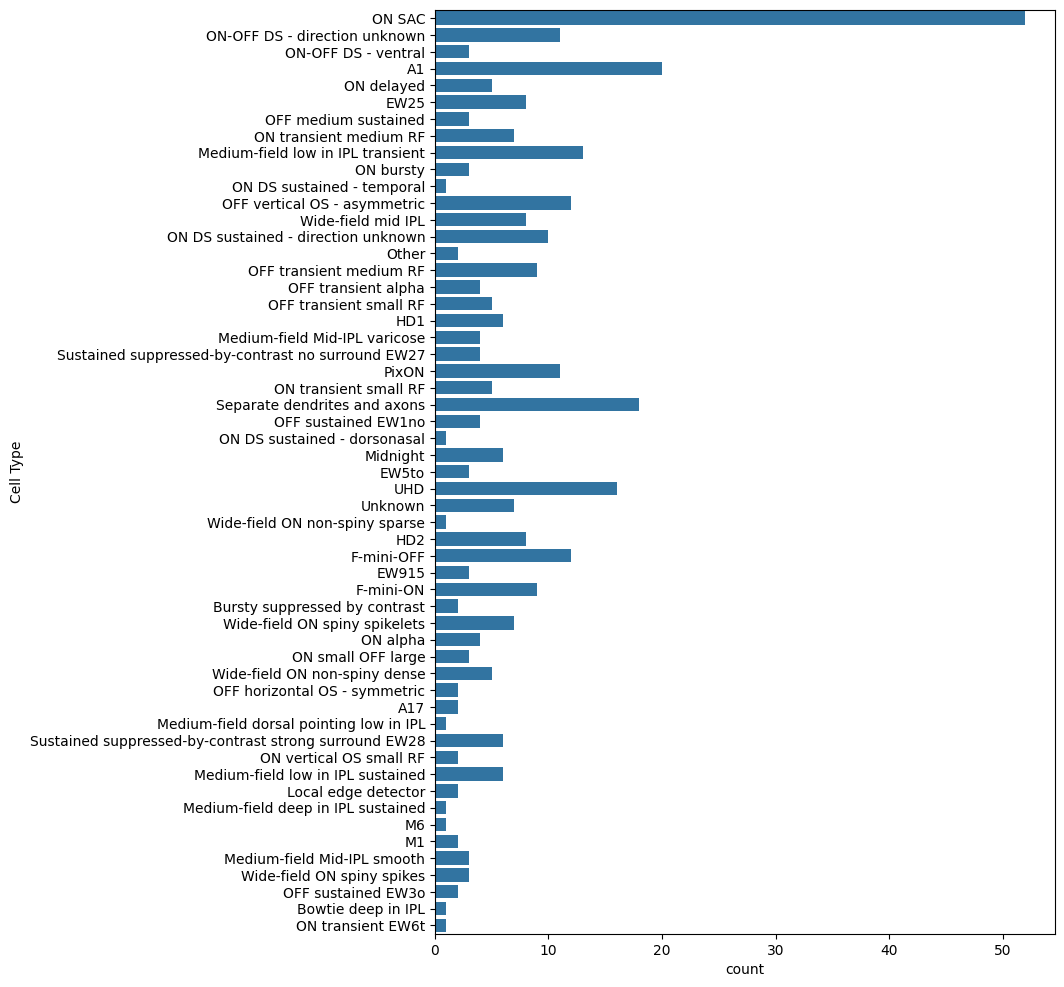

In [5]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

In [7]:
from eyewire2_functional_analysis import plot

def plot_cells(df):
    fig, axs = plt.subplots(len(df), 5, figsize=(6, len(df) * 0.8), width_ratios=(0.9, 0.5, 1.6, 1.6, 0.6))

    for i, ax_to_replace in enumerate(axs[:, -1]):
        ax_to_replace.remove()
        polar_ax = fig.add_subplot(ax_to_replace.get_subplotspec(), polar=True)
        axs[i, -1] = polar_ax

    all_xmin, all_xmax = [], []
    all_ymin, all_ymax = [], []
    
    for seg_id, row in df.iterrows():
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
    
        nodes = skel_rot.nodes[skel_rot.ntype == 3]
        nodes -= skel_rot.soma.center
        
        xmax, ymax, zmax = np.max(nodes, axis=0)
        xmin, ymin, zmin = np.min(nodes, axis=0)
    
        all_xmin.append(xmin)
        all_xmax.append(xmax)
        all_ymin.append(ymin)
        all_ymax.append(ymax)
    
    # Compute global limits with padding
    global_xlim = (min(all_xmin) - 13, max(all_xmax) + 3)
    global_ylim = (min(all_ymin) - 3, max(all_ymax) + 3)
    
    for i, (seg_id, row) in enumerate(df.iterrows()):
        ax = axs[i, 0]
        skel_rot = rotate_skel(row['skel'], rotation_deg=150)
        skel_rot.nodes -= skel_rot.soma.center

        sk.plot.projection(skel_rot,
                           ax=ax, xlim=global_ylim, ylim=global_xlim, plane='yx', draw_cylinders=False)
        plot.plot_scale_bar(ax=ax, x0=global_ylim[0] + 5, y0=np.mean(global_xlim),
                            size=100, text=False, unit='µm', tdist=0, orientation='v')
        ax.set_rasterized(True)

        ax = axs[i, 1]
        plot.plot_ipl_profile(ax=ax, row=row)

        ax = axs[i, 2]
        plot.plot_chirp(ax=ax, row=row)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 3]
        plot.plot_bar(ax=ax, row=row, annotate_dirs=False, annotate_symbols=i == 0, ventral_up=False)
        if i == (df.shape[0] - 1):
            plot.plot_scale_bar(ax=ax, x0=1, y0=-0.4, size=2, text=True, tdist=0.05, unit='s')
        ax.set_ylim(-0.5, +1.1)

        ax = axs[i, 4]
        plot.plot_bar_dir(ax=ax, row=row, ventral_up=False)

    for ax in axs[:, :-1].flat:
        ax.set(xlabel=None, ylabel=None, xticks=[], yticks=[])
        ax.axis('off')
        ax.set_facecolor((1, 1, 1, 0))

    plt.tight_layout(h_pad=0.5, w_pad=0.5)
    return fig, axs

In [8]:
df['swc_path'] = ''
df['skel'] = None

In [9]:
skel_dir = os.path.join(data_root, 'swc')

In [28]:
from eyewire2_functional_analysis.skeleton import rotate_skel
import skeliner as sk


def add_skels(df):
    df = df.copy()
    df['swc_path'] = df['Latest SegID'].apply(lambda x: os.path.join(skel_dir, f"{x}.swc"))
    df['skel'] = df.apply(lambda row: sk.io.load_swc(row['swc_path']) if os.path.isfile(row['swc_path']) else None, axis=1)
    return df

In [29]:
nuc_col_master = 'Final NucID'
seg_col_master = 'Latest SegID'

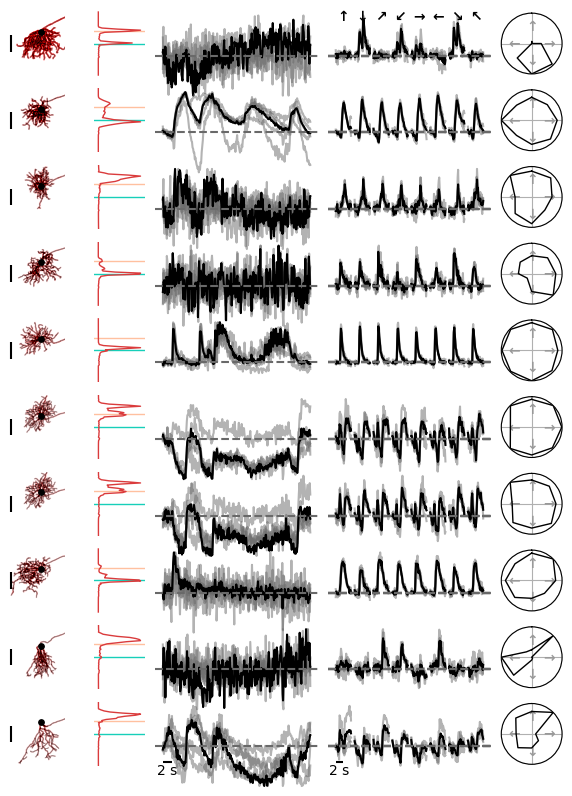

In [30]:
df_plot = add_skels(df[
    ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))  # Responsive
    & (df['Cell Class'] == 'RGC')  # RGCs only
].iloc[:10])
df_plot = df_plot[df_plot.skel.notnull()]

fig, axs = plot_cells(df_plot)
plt.show()

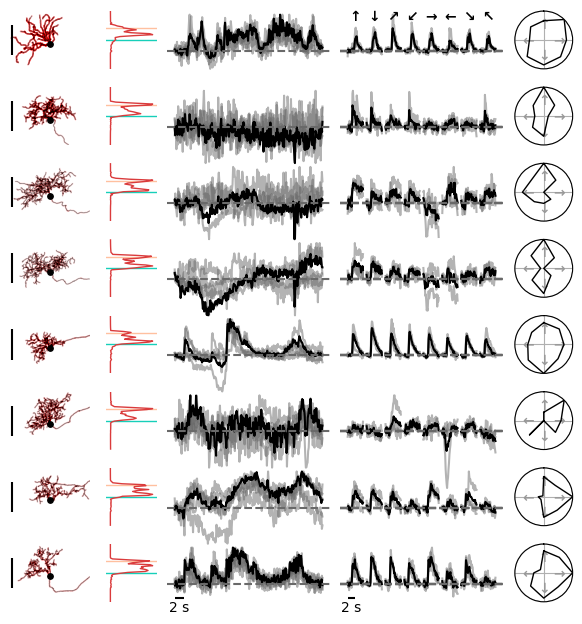

In [31]:
df_plot = add_skels(df[
    ((df.chirp_qidx > 0.45) | (df.bar_qidx > 0.6))  # Responsive
    & (df['Cell Type'] == 'F-mini-ON')  # F-mini-ON only
].iloc[:10])
df_plot = df_plot[df_plot.skel.notnull()]

fig, axs = plot_cells(df_plot)
plt.show()